In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('notebook')  # plot defaults


SyntaxError: invalid syntax (2617359710.py, line 4)

In [5]:
import xarray as xr
import salem
import numpy as np
import pandas as pd

In [11]:

import oggm.cfg
from oggm import utils, workflow, tasks, graphics
from oggm.sandbox.edu import run_constant_climate_with_bias

In [12]:
# OGGM options
oggm.cfg.initialize(logging_level='WARNING')
oggm.cfg.PATHS['working_dir'] = utils.gettempdir(dirname='WaterResources')
oggm.cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is defined when ice is thicker than 1m
oggm.cfg.PARAMS['store_model_geometry'] = True

2024-10-14 13:43:34: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2024-10-14 13:43:34: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2024-10-14 13:43:34: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2024-10-14 13:43:34: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.
2024-10-14 13:43:34: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.


In [13]:
rgi_id = 'RGI60-06.00291'


In [14]:
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5'
gdir = workflow.init_glacier_directories([rgi_id], from_prepro_level=5, prepro_border=80, prepro_base_url=base_url)[0]

2024-10-14 13:44:28: oggm.workflow: init_glacier_directories from prepro level 5 on 1 glaciers.
2024-10-14 13:44:28: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


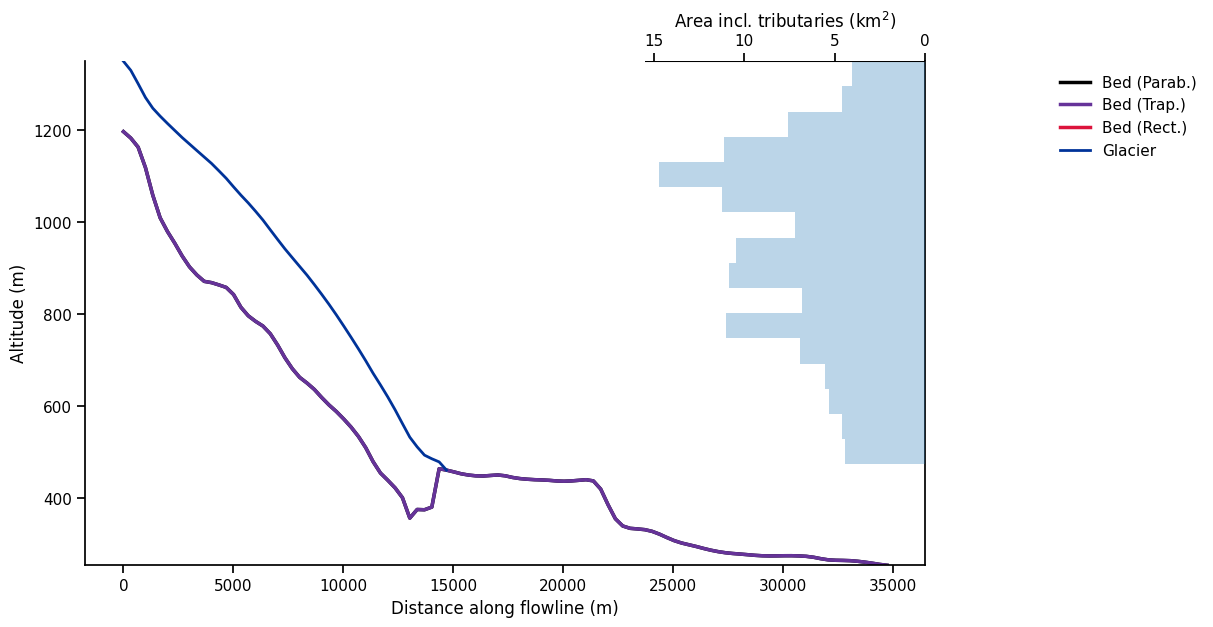

In [17]:
fls = gdir.read_pickle('model_flowlines')
graphics.plot_modeloutput_section(fls);

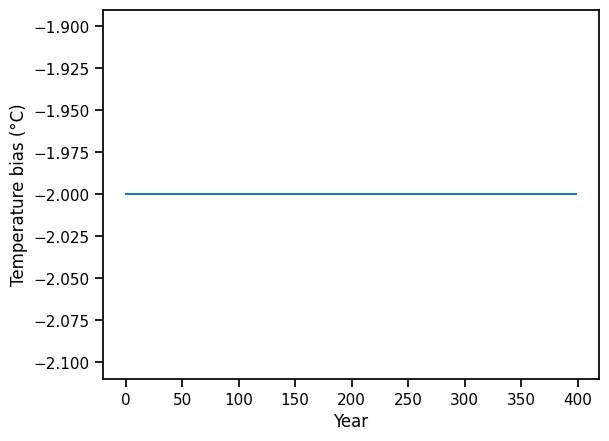

In [18]:
years = np.arange(400)
temp_bias_ts = pd.Series(years * 0. - 2, index=years)
temp_bias_ts.plot(); plt.xlabel('Year'); plt.ylabel('Temperature bias (°C)');

In [19]:
# file identifier where the model output is saved
file_id = '_spinup'

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
tasks.run_with_hydro(gdir,  # Run on the selected glacier
                     temp_bias_ts=temp_bias_ts,  # the temperature bias to apply to the average climate
                     run_task=run_constant_climate_with_bias,  # which climate scenario? See following notebook for other examples
                     y0=2009, halfsize=10,  # Period which we will average and constantly repeat
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

In [20]:
with xr.open_dataset(gdir.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds = ds.isel(time=slice(0, -1)).load()

In [21]:
ds

<xarray.Dataset> Size: 294kB
Dimensions:                       (time: 399, month_2d: 12)
Coordinates:
  * time                          (time) float64 3kB 0.0 1.0 2.0 ... 397.0 398.0
    calendar_year                 (time) int64 3kB 0 1 2 3 4 ... 395 396 397 398
    calendar_month                (time) int64 3kB 1 1 1 1 1 1 1 ... 1 1 1 1 1 1
    hydro_year                    (time) int64 3kB 0 1 2 3 4 ... 395 396 397 398
    hydro_month                   (time) int64 3kB 4 4 4 4 4 4 4 ... 4 4 4 4 4 4
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    hydro_month_2d                (month_2d) int64 96B 4 5 6 7 8 ... 11 12 1 2 3
    calendar_month_2d             (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
Data variables: (12/21)
    volume_m3                     (time) float64 3kB 2.673e+10 ... 6.721e+10
    volume_bsl_m3                 (time) float64 3kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    volume_bwl_m3                 (time) float64 3kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    area_m2                       (time) float64 3kB 1.265e+08 ... 1.6e+08
    length_m                      (time) float64 3kB 1.47e+04 ... 3.039e+04
    calving_m3                    (time) float64 3kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...                            ...
    liq_prcp_on_glacier           (time) float64 3kB 8.322e+10 ... 7.797e+10
    liq_prcp_on_glacier_monthly   (time, month_2d) float64 38kB 0.0 ... 2.515...
    snowfall_off_glacier          (time) float64 3kB 7.855e+10 7.854e+10 ... 0.0
    snowfall_off_glacier_monthly  (time, month_2d) float64 38kB 1.401e+10 ......
    snowfall_on_glacier           (time) float64 3kB 3.528e+11 ... 4.733e+11
    snowfall_on_glacier_monthly   (time, month_2d) float64 38kB 5.3e+10 ... 6...
Attributes:
    description:          OGGM model output
    oggm_version:         1.6.2
    calendar:             365-day no leap
    creation_date:        2024-10-14 13:46:06
    water_level:          0
    glen_a:               6.443823136176649e-24
    fs:                   0
    mb_model_class:       BiasedConstantMassBalance
    mb_model_hemisphere:  nh
    mb_model_rho:         900.0
    mb_model_ys:          0
    mb_model_ye:          399

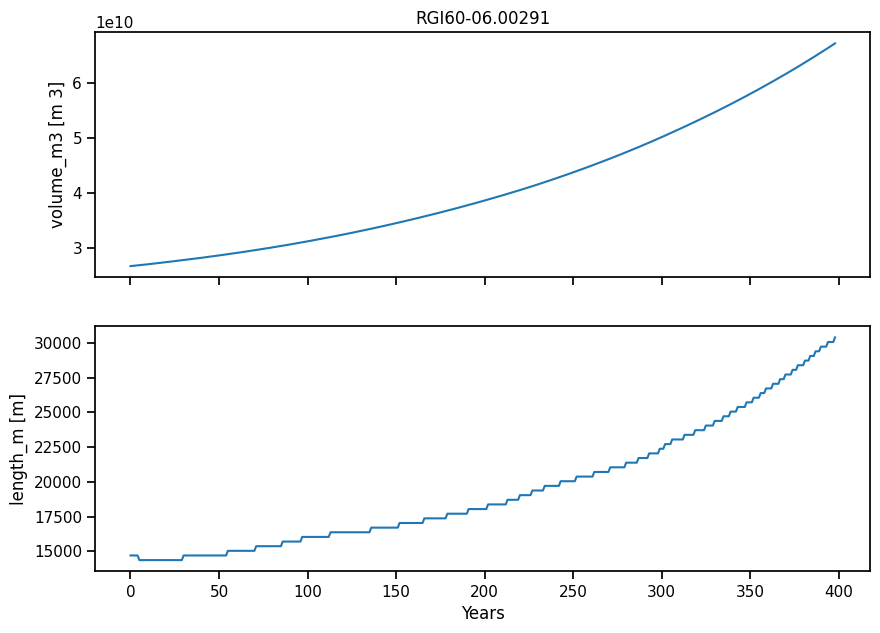

In [22]:
fig, axs = plt.subplots(nrows=2, figsize=(10, 7), sharex=True)
ds.volume_m3.plot(ax=axs[0]);
ds.length_m.plot(ax=axs[1]);
axs[0].set_xlabel(''); axs[0].set_title(f'{rgi_id}'); axs[1].set_xlabel('Years');

In [25]:
sel_vars = [v for v in ds.variables if 'month_2d' not in ds[v].dims]
df_annual = ds[sel_vars].to_dataframe()

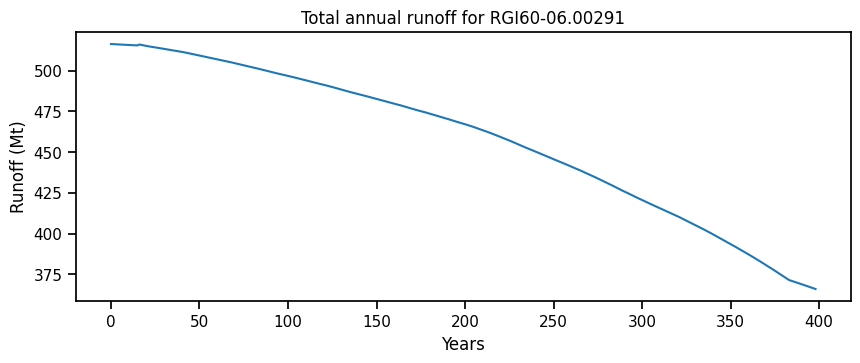

In [26]:
# Select only the runoff variables
runoff_vars = ['melt_off_glacier', 'melt_on_glacier', 'liq_prcp_off_glacier', 'liq_prcp_on_glacier']
# Convert them to megatonnes (instead of kg)
df_runoff = df_annual[runoff_vars] * 1e-9
# We smooth the output, which is otherwize noisy because of area discretization
df_runoff = df_runoff.rolling(31, center=True, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(10, 3.5), sharex=True)
df_runoff.sum(axis=1).plot(ax=ax);
plt.ylabel('Runoff (Mt)'); plt.xlabel('Years'); plt.title(f'Total annual runoff for {rgi_id}');

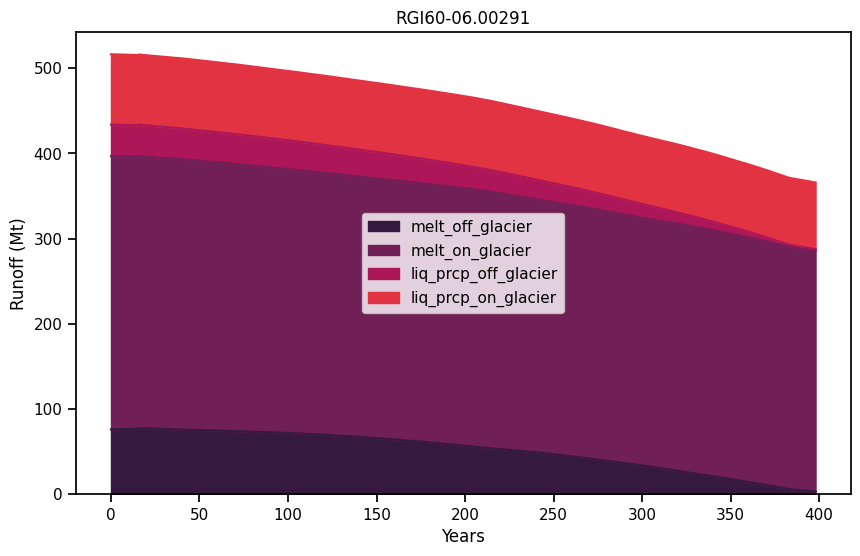

In [27]:
f, ax = plt.subplots(figsize=(10, 6));
df_runoff.plot.area(ax=ax, color=sns.color_palette('rocket')); plt.xlabel('Years'); plt.ylabel('Runoff (Mt)'); plt.title(rgi_id);

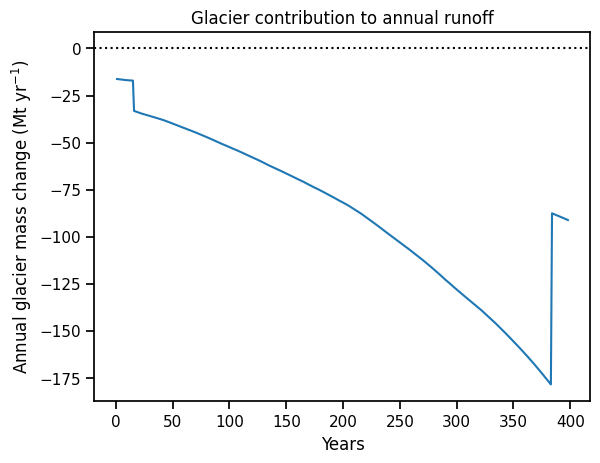

In [28]:
# Solution of the last question above
glacier_mass = ds.volume_m3.to_series() * oggm.cfg.PARAMS['ice_density'] * 1e-9  # In Megatonnes, Mt
glacier_mass = glacier_mass.rolling(31, center=True, min_periods=1).mean()
(- glacier_mass.diff()).plot()
plt.axhline(y=0, color='k', ls=':')
plt.ylabel('Annual glacier mass change (Mt yr$^{-1}$)')
plt.xlabel('Years'); plt.title('Glacier contribution to annual runoff');

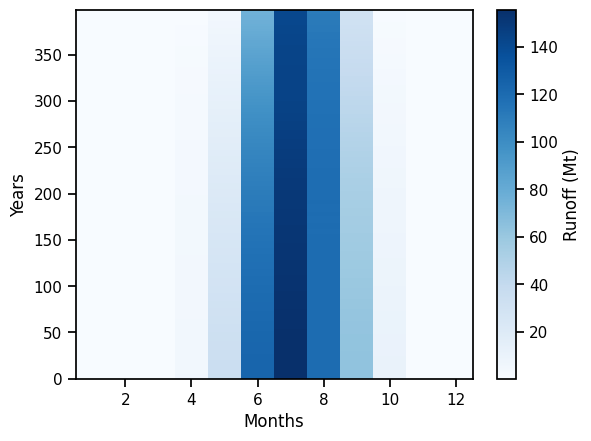

In [29]:
# Select only the runoff variables and convert them to megatonnes (instead of kg)
monthly_runoff = ds['melt_off_glacier_monthly'] + ds['melt_on_glacier_monthly'] + ds['liq_prcp_off_glacier_monthly'] + ds['liq_prcp_on_glacier_monthly']
monthly_runoff = monthly_runoff.rolling(time=31, center=True, min_periods=1).mean() * 1e-9
monthly_runoff.clip(0).plot(cmap='Blues', cbar_kwargs={'label': 'Runoff (Mt)'}); plt.xlabel('Months'); plt.ylabel('Years');

In [30]:
# Compute total precipitation (Snow + Liquid)
tot_precip = ds['liq_prcp_off_glacier_monthly'] + ds['liq_prcp_on_glacier_monthly'] + ds['snowfall_off_glacier_monthly'] + ds['snowfall_on_glacier_monthly']
tot_precip *= 1e-9  # in Mt

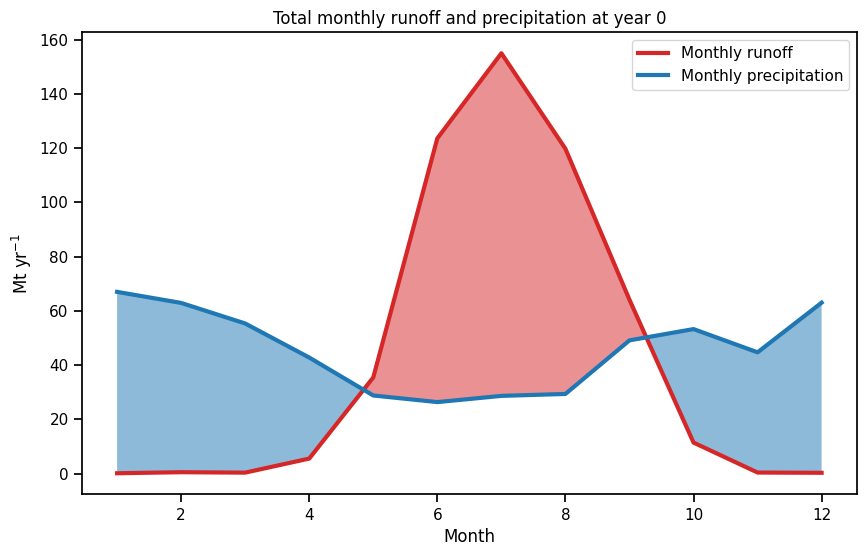

In [31]:
# Plot these data at year 0
yr = 0
r = monthly_runoff.sel(time=yr)
p = tot_precip.sel(time=yr)

f, ax = plt.subplots(figsize=(10, 6));
r.plot(ax=ax, color='C3', label='Monthly runoff', linewidth=3);
p.plot(ax=ax, color='C0', label='Monthly precipitation', linewidth=3);
ax.fill_between(r.month_2d, r, p, where=(p >= r), facecolor='C0', interpolate=True, alpha=0.5)
ax.fill_between(r.month_2d, r, p, where=(r > p), facecolor='C3', interpolate=True, alpha=0.5)
plt.ylabel('Mt yr$^{-1}$'); plt.legend(loc='best');
plt.xlabel('Month'); plt.title(f'Total monthly runoff and precipitation at year {yr}');

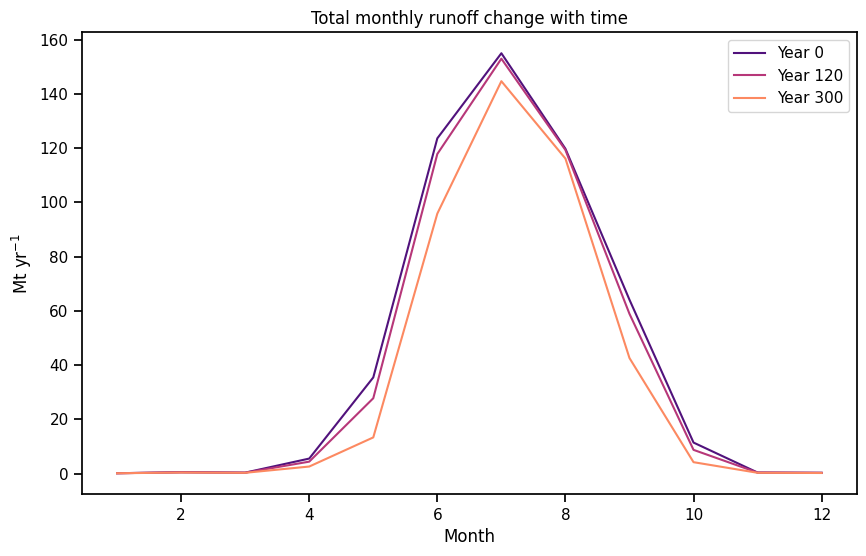

In [32]:
f, ax = plt.subplots(figsize=(10, 6));
cmap = sns.color_palette('magma', 3)
for i, yr in enumerate([0, 120, 300]):
    monthly_runoff.sel(time=yr).plot(ax=ax, color=cmap[i], label=f'Year {yr}')
plt.ylabel('Mt yr$^{-1}$'); plt.legend(loc='best');
plt.xlabel('Month'); plt.title('Total monthly runoff change with time');

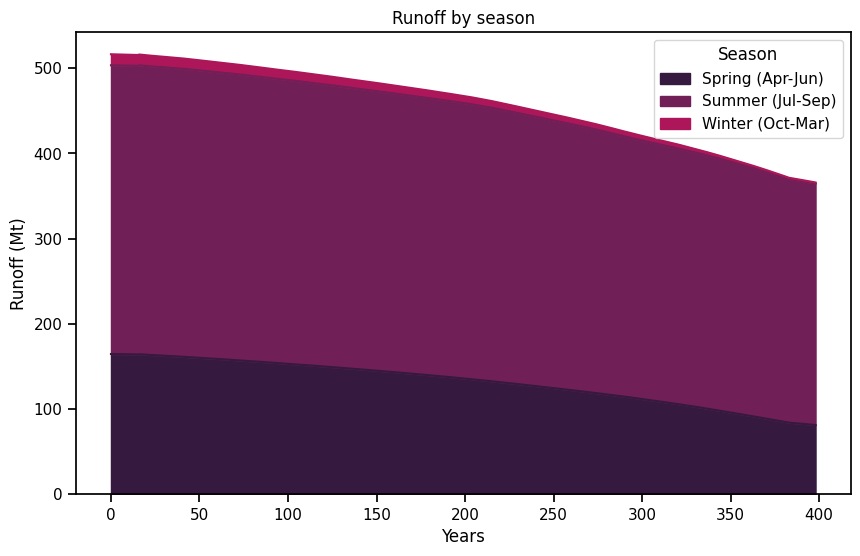

In [33]:
# Make a dataframe out of the xarray dataset for simplicity
df_monthly_runoff = pd.DataFrame(monthly_runoff.data, index=ds.time, columns=monthly_runoff.month_2d)

# Create new columns for each season (we define seasons from the perspective of the northern Hemisphere)
df_monthly_runoff['Spring (Apr-Jun)'] = df_monthly_runoff[[4, 5, 6]].sum(axis=1)
df_monthly_runoff['Summer (Jul-Sep)'] = df_monthly_runoff[[7, 8, 9]].sum(axis=1)
df_monthly_runoff['Winter (Oct-Mar)'] = df_monthly_runoff[[10, 11, 12, 1, 2, 3]].sum(axis=1)
df_monthly_runoff.columns.name = 'Season'

# Plot it
# Attention the seasons and labels might need to be adapted if a glacier in a different region is used!
f, ax = plt.subplots(figsize=(10, 6));
df_monthly_runoff[['Spring (Apr-Jun)', 'Summer (Jul-Sep)', 'Winter (Oct-Mar)']].plot.area(ax=ax, color=sns.color_palette('rocket'));
plt.xlabel('Years'); plt.ylabel('Runoff (Mt)'); plt.title('Runoff by season');

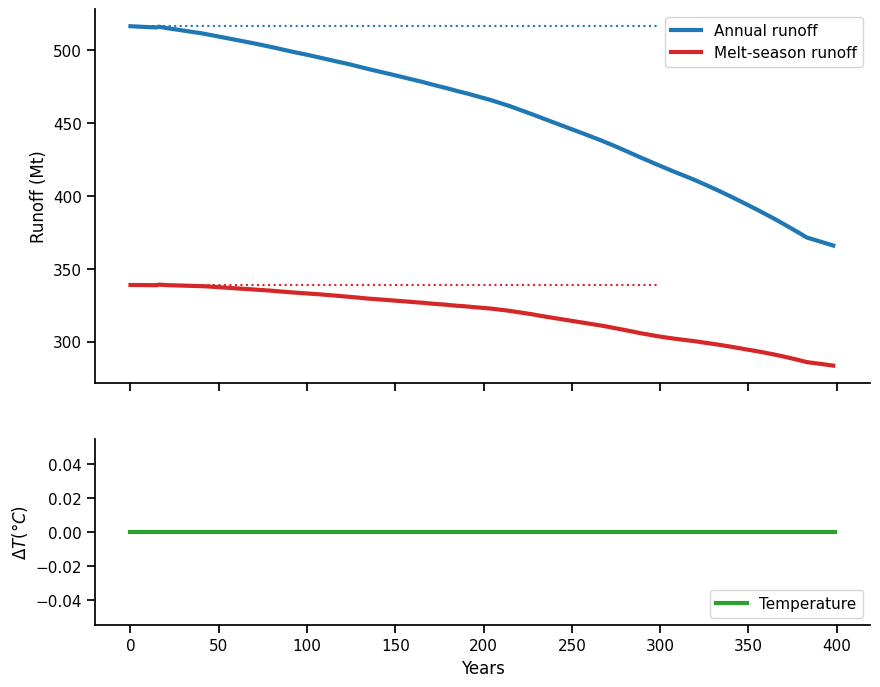

In [34]:
f, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [2, 1]}, figsize=(10, 8), sharex=True)

p1 = df_monthly_runoff[['Spring (Apr-Jun)', 'Summer (Jul-Sep)', 'Winter (Oct-Mar)']].sum(axis=1)
p2 = df_monthly_runoff['Summer (Jul-Sep)'] # July to September is here the melt season
p1.plot(ax=ax1, color='C0', label='Annual runoff', linewidth=3)
p2.plot(ax=ax1, color='C3', label='Melt-season runoff', linewidth=3);
ax1.hlines([p1.loc[0], p2.loc[0]], 0, 300, color=['C0', 'C3'], linestyle=[':']);
ax1.legend(); ax1.set_xlabel(''); ax1.set_ylabel('Runoff (Mt)');

(temp_bias_ts + 2).plot(ax=ax2, color='C2', label='Temperature', linewidth=3);
ax2.legend(loc='lower right'); ax2.set_xlabel('Years'); ax2.set_ylabel('$\Delta T (°C)$');
sns.despine();

In [47]:
rgi_ids = [rgi_id, 'RGI60-06.00291']

In [49]:
# you can choose one of these 5 different GCMs:
# 'gfdl-esm4_r1i1p1f1', 'mpi-esm1-2-hr_r1i1p1f1', 'mri-esm2-0_r1i1p1f1' ("low sensitivity" models, within typical ranges from AR6)
# 'ipsl-cm6a-lr_r1i1p1f1', 'ukesm1-0-ll_r1i1p1f2' ("hotter" models, especially ukesm1-0-ll)
from oggm.shop import gcm_climate
member = 'mri-esm2-0_r1i1p1f1' 

# Download the three main SSPs
for ssp in ['ssp126', 'ssp370','ssp585']:
    # bias correct them
    workflow.execute_entity_task(gcm_climate.process_monthly_isimip_data, gdirs, 
                                 ssp = ssp,
                                 # gcm member -> you can choose another one
                                 member=member,
                                 # recognize the climate file for later
                                 output_filesuffix=f'_ISIMIP3b_{member}_{ssp}'
                                 );

NameError: name 'gdirs' is not defined